# **RNN training procedure**


In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    #update for your local path
    %cd /home/jacob/kalnet

/home/jacob/kalnet


In [1]:
#Imports

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from kalnet.model import KalmanRNN
from kalnet.task import KalmanFilteringTask
from kalnet.train import (
    DEFAULT_CHECKPOINT,
    load_checkpoint,
    train,
)
from kalnet.task_vec import KalmanFilteringTask as KalmanFilteringTask_vec
from kalnet.train_vec import train as train_vec


## RNN with batch_size = 10

In [13]:
#make sure you are in the /content/kalnet directory when running this
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = REPO_ROOT / DEFAULT_CHECKPOINT
print(f"device={DEVICE}, checkpoint={CHECKPOINT}")
if DEVICE == "cpu":
    print("Note: CUDA unavailable here; full 50k run will be slower on CPU.")

device=cuda, checkpoint=/home/jacob/kalnet/kalnet/checkpoints/kf_allgains.pt


In [4]:
# Skip if there is already a trained network saved
result = train(
    max_iter=50_001,
    test_iter=2_501,
    batch_size=10,
    log_every=500,
    lr=2e-4,
    tr_cond="all_gains",
    test_cond="all_gains",
    seed=SEED,
    device=DEVICE,
    save_path=CHECKPOINT,
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved {CHECKPOINT.resolve()}"
)

Batch #0; Frac. RMSE: 5.924677; Opt. RMSE: 0.466650; Net. RMSE: 3.231403
Batch #500; Frac. RMSE: 1.550849; Opt. RMSE: 0.447285; Net. RMSE: 1.140957


KeyboardInterrupt: 

Fractional RMSE learning curve

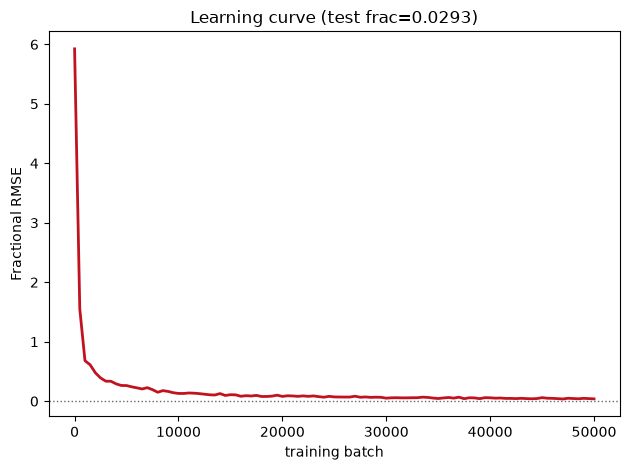

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 10,
 'lr': 0.0002,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 50001}

In [5]:
loaded = load_checkpoint("checkpoints/kf_allgains_def.pt", device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

Weights representation

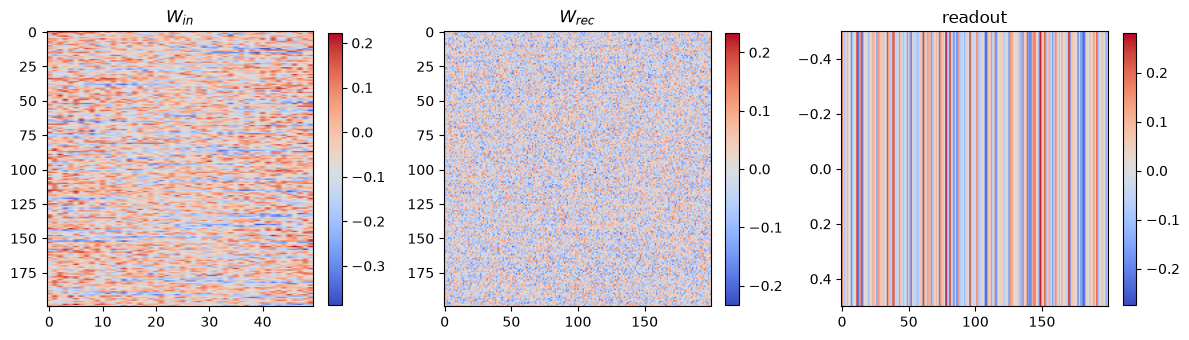

In [6]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [15]:
checkpoint = torch.load("checkpoints/kf_allgains_def.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

x = torch.from_numpy(batch.input)
y_true = torch.from_numpy(batch.target)
y_opt = torch.from_numpy(batch.opt_mean)

with torch.no_grad():
    y_hat = net(x)

rmse_net = torch.sqrt(torch.mean((y_hat - y_true) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((y_opt - y_true) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.5113
Optimal RMSE:    0.4487
Fractional RMSE: 13.93%


## RNN with batch=100

In [2]:
# Skip if there is already a trained network saved
result = train_vec(batch_size=100, max_iter=20000, save_path="checkpoints/kf_batch100.pt")

Batch #0; Frac. RMSE: 4.766254; Opt. RMSE: 0.439837; Net. RMSE: 2.536209
Batch #500; Frac. RMSE: 0.709649; Opt. RMSE: 0.453390; Net. RMSE: 0.775137
Batch #1000; Frac. RMSE: 0.200928; Opt. RMSE: 0.452952; Net. RMSE: 0.543963
Batch #1500; Frac. RMSE: 0.119413; Opt. RMSE: 0.453233; Net. RMSE: 0.507355
Batch #2000; Frac. RMSE: 0.080322; Opt. RMSE: 0.452350; Net. RMSE: 0.488684
Batch #2500; Frac. RMSE: 0.058558; Opt. RMSE: 0.452392; Net. RMSE: 0.478883
Batch #3000; Frac. RMSE: 0.047463; Opt. RMSE: 0.452502; Net. RMSE: 0.473979
Batch #3500; Frac. RMSE: 0.038132; Opt. RMSE: 0.452588; Net. RMSE: 0.469846
Batch #4000; Frac. RMSE: 0.031645; Opt. RMSE: 0.453959; Net. RMSE: 0.468324
Batch #4500; Frac. RMSE: 0.026692; Opt. RMSE: 0.452747; Net. RMSE: 0.464832
Batch #5000; Frac. RMSE: 0.023579; Opt. RMSE: 0.452820; Net. RMSE: 0.463497
Batch #5500; Frac. RMSE: 0.021742; Opt. RMSE: 0.453073; Net. RMSE: 0.462924
Batch #6000; Frac. RMSE: 0.016878; Opt. RMSE: 0.452913; Net. RMSE: 0.460557
Batch #6500; Fra

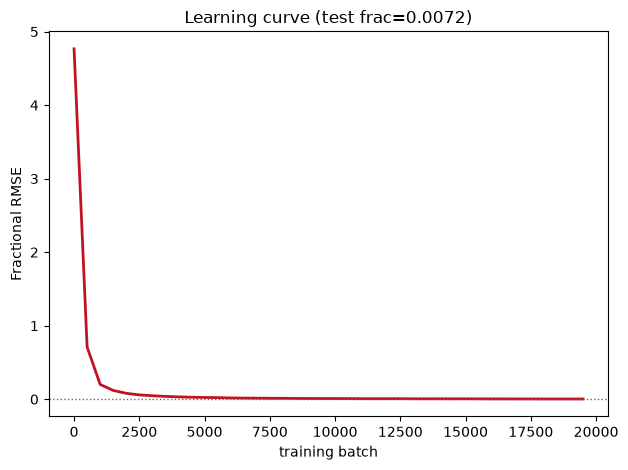

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 100,
 'lr': 0.0003,
 'l2_penalty': 1e-06,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 20000}

In [20]:
loaded = load_checkpoint("checkpoints/kf_allgains_batch100.pt", device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

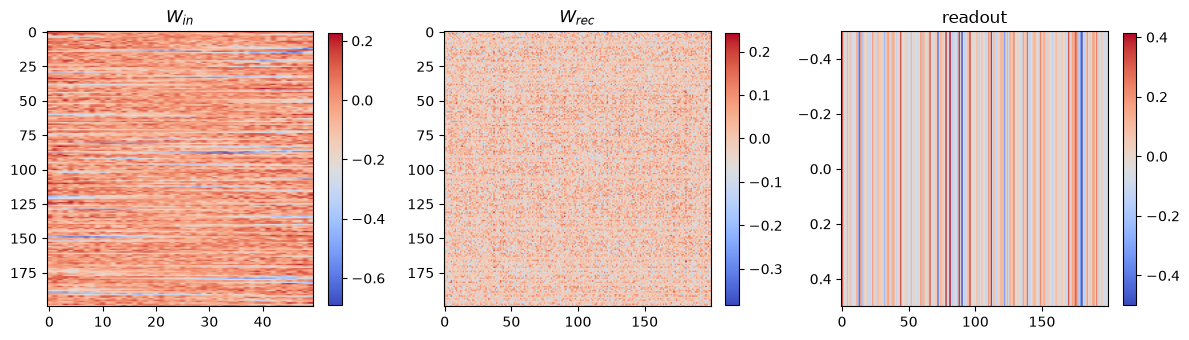

In [21]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

Test network performance

In [26]:
checkpoint = torch.load("checkpoints/kf_allgains_batch100.pt", map_location="cpu", weights_only=False)
net = KalmanRNN(n_in=checkpoint["config"]["n_in"], n_hid=checkpoint["config"]["n_hid"], n_out=1)
net.load_state_dict(checkpoint["state_dict"])
net.eval()

test_task = KalmanFilteringTask_vec(batch_size=2000, tr_cond="all_gains", seed=999)
batch = test_task.sample(include_internals=True)

with torch.no_grad():
    y_hat = net(batch.input)  # (batch, T, 1)

rmse_net = torch.sqrt(torch.mean((y_hat - batch.target) ** 2)).item()
rmse_opt = torch.sqrt(torch.mean((batch.opt_mean - batch.target) ** 2)).item()
frac_rmse = 100 * (rmse_net - rmse_opt) / rmse_opt

print(f"Net RMSE:        {rmse_net:.4f}")
print(f"Optimal RMSE:    {rmse_opt:.4f}")
print(f"Fractional RMSE: {frac_rmse:.2f}%")

Net RMSE:        0.4588
Optimal RMSE:    0.4557
Fractional RMSE: 0.68%
